# TCBench: Quick Start

**Goal.** This notebook demonstrates a minimal, end-to-end workflow to evaluate tropical-cyclone (TC) **track** and **intensity** forecasts on the **2023** test year using the TCBench toolbox and local CSV files.  
It loads IBTrACS, loads one or more model track CSVs, runs the evaluation (or loads the corresponding `*_results.csv` if already computed), and renders compact figures and DataFrame previews so that every step is transparent.

**What you’ll see (at a glance):**
- A quick preview (`.head()`) of **IBTrACS** after light preprocessing (e.g., 6-hour grid, 00/12Z inits).  
- A preview of **model track CSVs** (columns & a few rows).  
- A preview of **evaluation outputs** (columns & a few rows) for both deterministic and probabilistic metrics.  
- Simple plots mirroring the figures in the paper for a minimal subset (to keep runtime short).

> This notebook is **self-contained, offline, and anonymized** (relative paths only; no external calls).

### Add-Your-Own Model (One-Minute Setup)

1. Export your model’s TC track forecasts for **2023** (00/12Z inits; 6-hourly leads up to 120 h).  
2. Save as `output/<your_model>.csv` using the schema above.  
3. Re-run the **evaluation** cell—your file will be detected automatically, evaluated (or loaded), and included in the previews and plots.


In [1]:
# Install requirements into the *current* Jupyter kernel 
%pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


## Load the IBTrACS test set (ground truth)
**IBTrACS** (International Best Track Archive for Climate Stewardship) is the
global reference archive of tropical cyclone “best tracks,” compiled from all
basin warning centers and harmonized by NOAA. It provides a consistent,
time-ordered record of each storm’s location and intensity through its life
cycle. We use IBTrACS as the **ground truth** for verifying model tracks and
intensities.

The file we load here (`data/ibtracs/ibtracs.ALL.list.v04r01.csv`) contains the
global record; in this notebook we subset to **2023** and verify on the
standard **6-hour grid** (00/06/12/18 UTC) with intensities referenced to the
“USA” source used in IBTrACS.

---

### Columns used in ibtracs

| Column        | Type / Units                 | Description                                                                                             | Notes |
|---            |---                           |---                                                                                                      |---|
| `SID`         | string                       | Unique storm identifier within IBTrACS.                                                                 | Stable key used to group track points belonging to the same cyclone. |
| `SEASON`      | integer (year)               | Season year of the storm.                                                                               | We filter to `SEASON == 2023`. |
| `BASIN`       | categorical                  | Basin code (e.g., `NA` North Atlantic, `WP` West Pacific, `EP` East Pacific, `NI` North Indian, `SI` South Indian, `SP` South Pacific). |  |
| `SUBBASIN`    | categorical / string         | Sub-basin code where available.                                                                         | |
| `NAME`        | string                       | Storm name (if assigned).                                                                               |  |
| `ISO_TIME`    | datetime (UTC, ISO-8601)     | Analysis time for this record.                                                                          | Nominally 6-hourly; occasionally higher frequency. Convert with `pd.to_datetime(..., utc=True)` and floor to the hour if needed. |
| `NATURE`      | categorical                  | Storm nature/class (e.g., `TROPICAL`, `SUBTROPICAL`, `EXTRATROPICAL`, `REMNANT LOW`, `DISTURBANCE`).     | |
| `LAT`         | float (degrees)              | Storm center latitude.                                                                                  |  |
| `LON`         | float (degrees)              | Storm center longitude.                                                                                 |  |
| `USA_ATCF_ID` | string                       | ATCF storm identifier from the USA source (e.g., `AL012023`, `WP192023`).                               |  |
| `USA_WIND`    | float (knots)                | **Maximum 1-minute sustained wind** from the USA source at `ISO_TIME`.                                  | Used as ground-truth intensity for wind. Missing values appear as NaN. |
| `USA_PRES`    | float (hPa)                  | **Minimum central pressure** from the USA source at `ISO_TIME`.                                         | Used as ground-truth intensity for pressure. Missing values appear as NaN. |


In [2]:
from utils import toolbox

ibtracs = toolbox.read_hist_track_file(tracks_path="/home/mgomezd1/Downloads/TCBench/data/ibtracs")

ibtracs = ibtracs[ibtracs["ISO_TIME"].dt.year == 2023]
ibtracs.sample(5)

/home/mgomezd1/envs/tcbench/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,SID,SEASON,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,USA_ATCF_ID,USA_WIND,USA_PRES
707397,2023156N10067,2023,NI,AS,BIPARJOY,2023-06-12 18:00:00,TS,20.203125,67.1875,IO022023,85,959
705607,2023005S18142,2023,SP,EA,HALE,2023-01-07 03:00:00,TS,-20.796875,155.6250,SH072023,45,992
707961,2023194N16123,2023,WP,MM,TALIM,2023-07-17 12:00:00,TS,21.203125,110.8750,WP042023,75,967
706157,2023036S12117,2023,SI,MM,FREDDY,2023-02-19 03:00:00,TS,-16.796875,66.1875,SH112023,135,930
711403,2023314N05149,2023,WP,MM,UNNAMED,2023-11-12 15:00:00,TS,7.601562,139.7500,WP172023,25,998


### Evaluate and materialize results (then preview )

This cell runs the **evaluation pipeline** over all model track CSVs found in `outputs/` and
verifies them against **IBTrACS 2023** (`data/ibtracs`). Concretely, it:

1) **Discovers** candidate input files in `outputs/` (e.g., `2023_PANGU.csv`, `2023_aifs.csv`, …).  
2) **Matches** each track to IBTrACS on the standardized 6-hour grid (00/12Z inits, 6–120 h leads).  
3) **Computes metrics** and writes them to disk as `<name>_results.csv`.  
   - Deterministic: track errors (DPE/Along/Cross), intensity errors (AE/SE), etc.  
   - Probabilistic (if ensemble): CRPS variants are added as `*_mean` / `*_std`.  
4) **Generates/refreshes RI files** (`<name>_RI.csv`) so RI plots can be made later.  
5) Returns a couple of convenience objects:
   - `result_paths`: where each results file was written.  
   - `all_cases`: the evaluated `(SID, Initial Time, Valid Time)` pairs (useful for FAIR/coverage).


**Recompute?** By default `recompute=False`, so existing `<name>_results.csv` files are **reused** and
only **new** inputs are computed. Set `recompute=True` if you want to **overwrite** the results.

Below, we print a small random sample of PANGU’s deterministic metrics and GENC's probabilistic ones to show the schema.

In [3]:
%load_ext autoreload

In [4]:
%autoreload

In [5]:
from evaluate_tracks import evaluate_tracks
import pandas as pd

eval_dir = "/home/mgomezd1/Downloads/TCBench/outputs"
ib_dir = "/home/mgomezd1/Downloads/TCBench/data/ibtracs"

result_paths, result_dfs, all_cases = evaluate_tracks(
    eval_folder=eval_dir,
    ibtracs_tracks_path=ib_dir,
    year=2023,
    select_files=["2023_PANGU.csv"],  # ex: ["2023_PANGU.csv", "2023_GENC.csv"]
    recompute=True,
    only_ri=False,
    exclude_patterns=("RI", "results", "ibtracs"),
    save_results=True,
    return_dataframes=False,
    verbose=True,
)

# Example: preview one model's results
pangu_results_df = pd.read_csv("/home/mgomezd1/Downloads/TCBench/outputs/2023_PANGU_results.csv")
print("Example: PANGU results (Deterministic metrics)")
pangu_results_df.sample(5)

Candidates in '/home/mgomezd1/Downloads/TCBench/outputs': 1 | to compute (recompute=True): 1
['2023_PANGU.csv']

Working on 2023_PANGU.csv...
Calculating DPE...
Calculating AE...
Calculating SE...
Calculating CARTE...
Overwriting existing results: /home/mgomezd1/Downloads/TCBench/outputs/2023_PANGU_results.csv
[RI] Recomputing RI file for 2023_PANGU.csv...
Saved RI file: /home/mgomezd1/Downloads/TCBench/outputs/2023_PANGU_RI.csv
Example: PANGU results (Deterministic metrics)


,SID,Initial Time,Valid Time,wind max,pressure min,lat,lon,DPE_GCD,AE_wind,AE_pressure,SE_wind,SE_pressure,Along_TE,Cross_TE,DPE_cart
6797,2023249N12320,2023-09-12 12:00:00,2023-09-13 12:00:00,57.459094,967.3321,26.00,292.75,6.263525,37.540906,17.3321,1409.319624,300.401690,0.000000,6.246334,6.246334
3733,2023228N12259,2023-08-13 00:00:00,2023-08-15 18:00:00,21.592019,1007.3870,10.25,256.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10979,2023349N04141,2023-12-16 12:00:00,2023-12-17 00:00:00,26.930543,1006.0460,7.25,130.00,39.075757,1.930543,2.0460,3.726994,4.186116,0.000000,45.021954,45.021954
834,2023156N12135,2023-06-10 12:00:00,2023-06-12 18:00:00,42.397114,982.5091,33.00,142.50,117.018089,2.602886,5.4909,6.775017,30.149983,0.000000,126.190368,126.190368
1681,2023194N16123,2023-07-11 12:00:00,2023-07-15 18:00:00,32.940546,990.2888,17.75,117.25,115.529785,7.059454,0.7112,49.835892,0.505805,81.183695,83.093233,116.169177


In [6]:
print("Example: GENC results (Probabilistic metrics)")
genc_results_df = pd.read_csv("/home/mgomezd1/Downloads/TCBench/outputs/2023_GENC_results.csv")
genc_results_df.sample(5)

Example: GENC results (Probabilistic metrics)


,SID,Initial Time,Valid Time,lat,lon,wind max,pressure min,Hour,DPE_GCD_mean,DPE_GCD_std,...,DPE_cart_mean,Along_TE_std,Cross_TE_std,DPE_cart_std,CRPS_vmax_mean,CRPS_pmin_mean,CRPS_vmax_std,CRPS_pmin_std,CRPS_haversine_mean,CRPS_haversine_std
9013,2023271N14144,2023-10-06 00:00:00,2023-10-10 18:00:00,17.88,109.62,38.7,1002.9,114.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
308,2023055S14184,2023-02-28 00:00:00,2023-03-09 06:00:00,-40.88,201.38,80.7,973.2,222.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8891,2023271N14144,2023-10-04 00:00:00,2023-10-11 06:00:00,17.88,110.87,30.0,1007.8,174.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7870,2023266N16323,2023-09-24 00:00:00,2023-09-25 06:00:00,17.13,315.25,32.9,1006.2,30.0,88.239773,34.807744,...,92.475990,9.270305,49.262513,48.367349,15.895837,7.512082,NaN,NaN,58.647564,NaN
7275,2023249N12320,2023-09-13 12:00:00,2023-09-18 00:00:00,48.25,300.75,50.0,996.0,108.0,241.365937,116.992485,...,508.714785,312.740709,291.307915,328.178876,16.830776,0.775020,NaN,NaN,95.879825,NaN


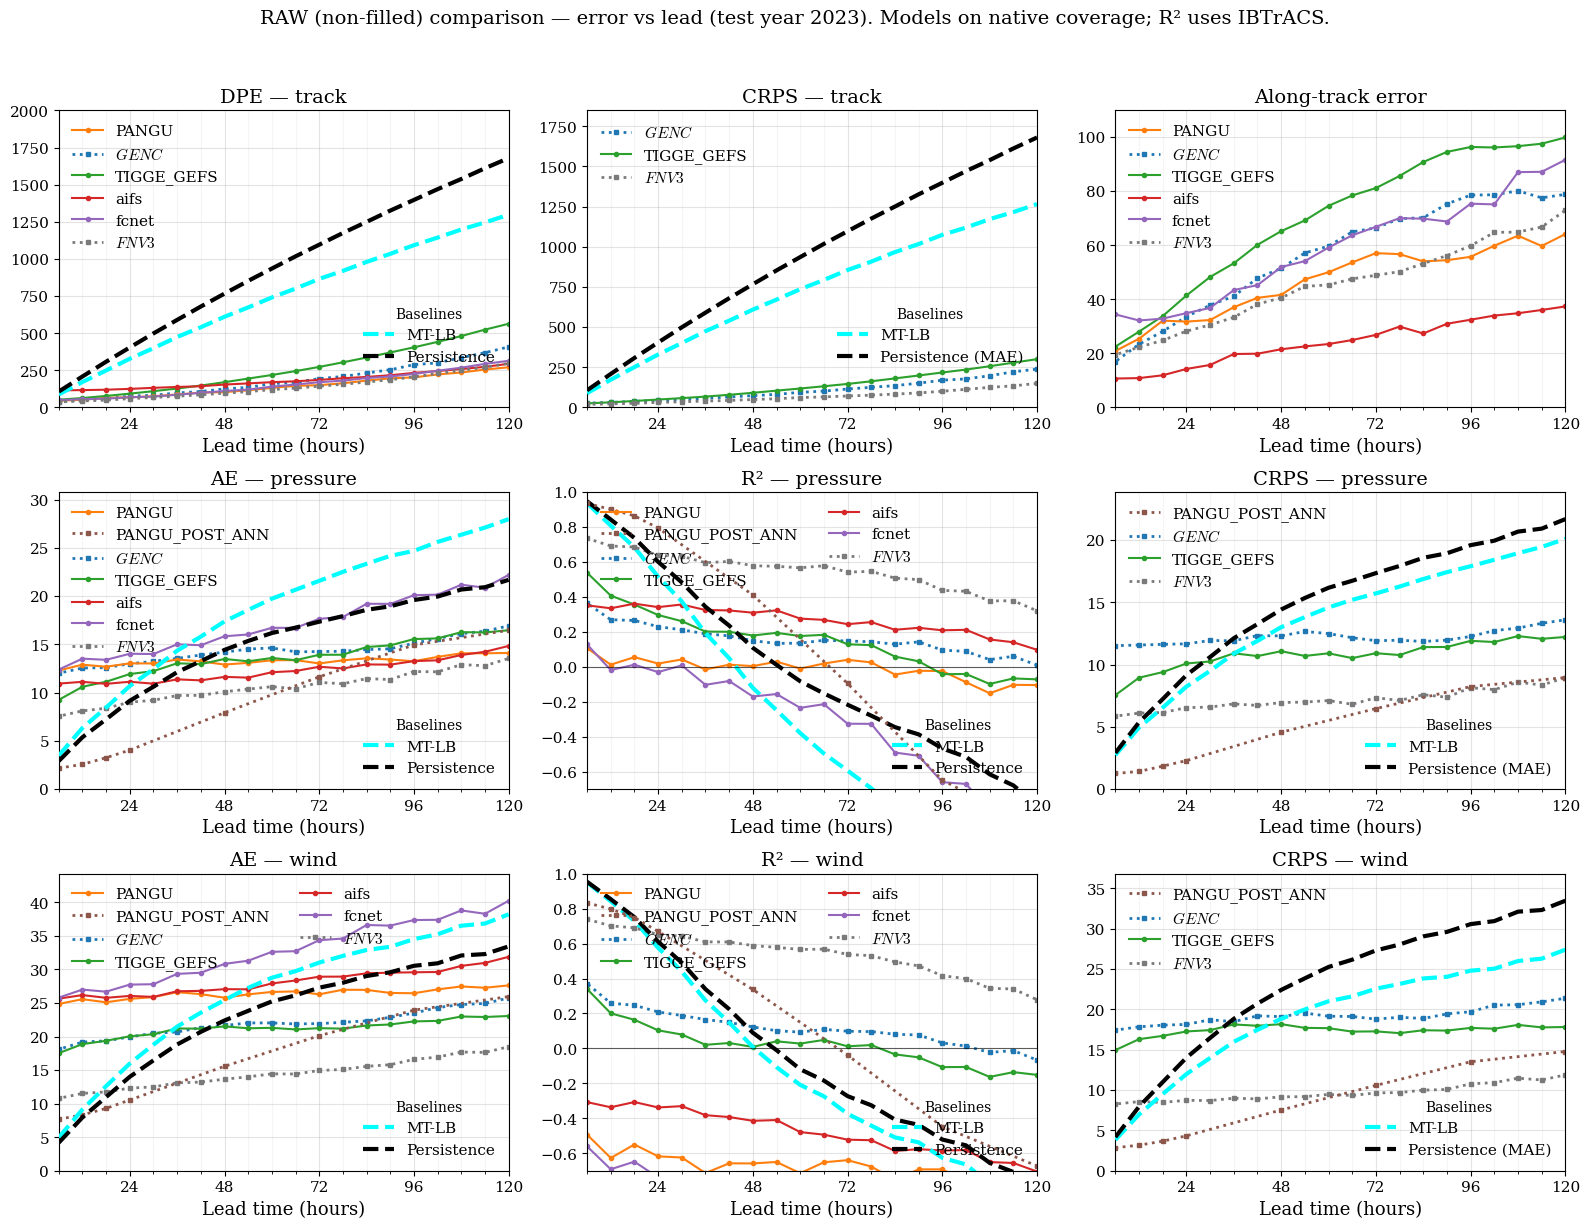

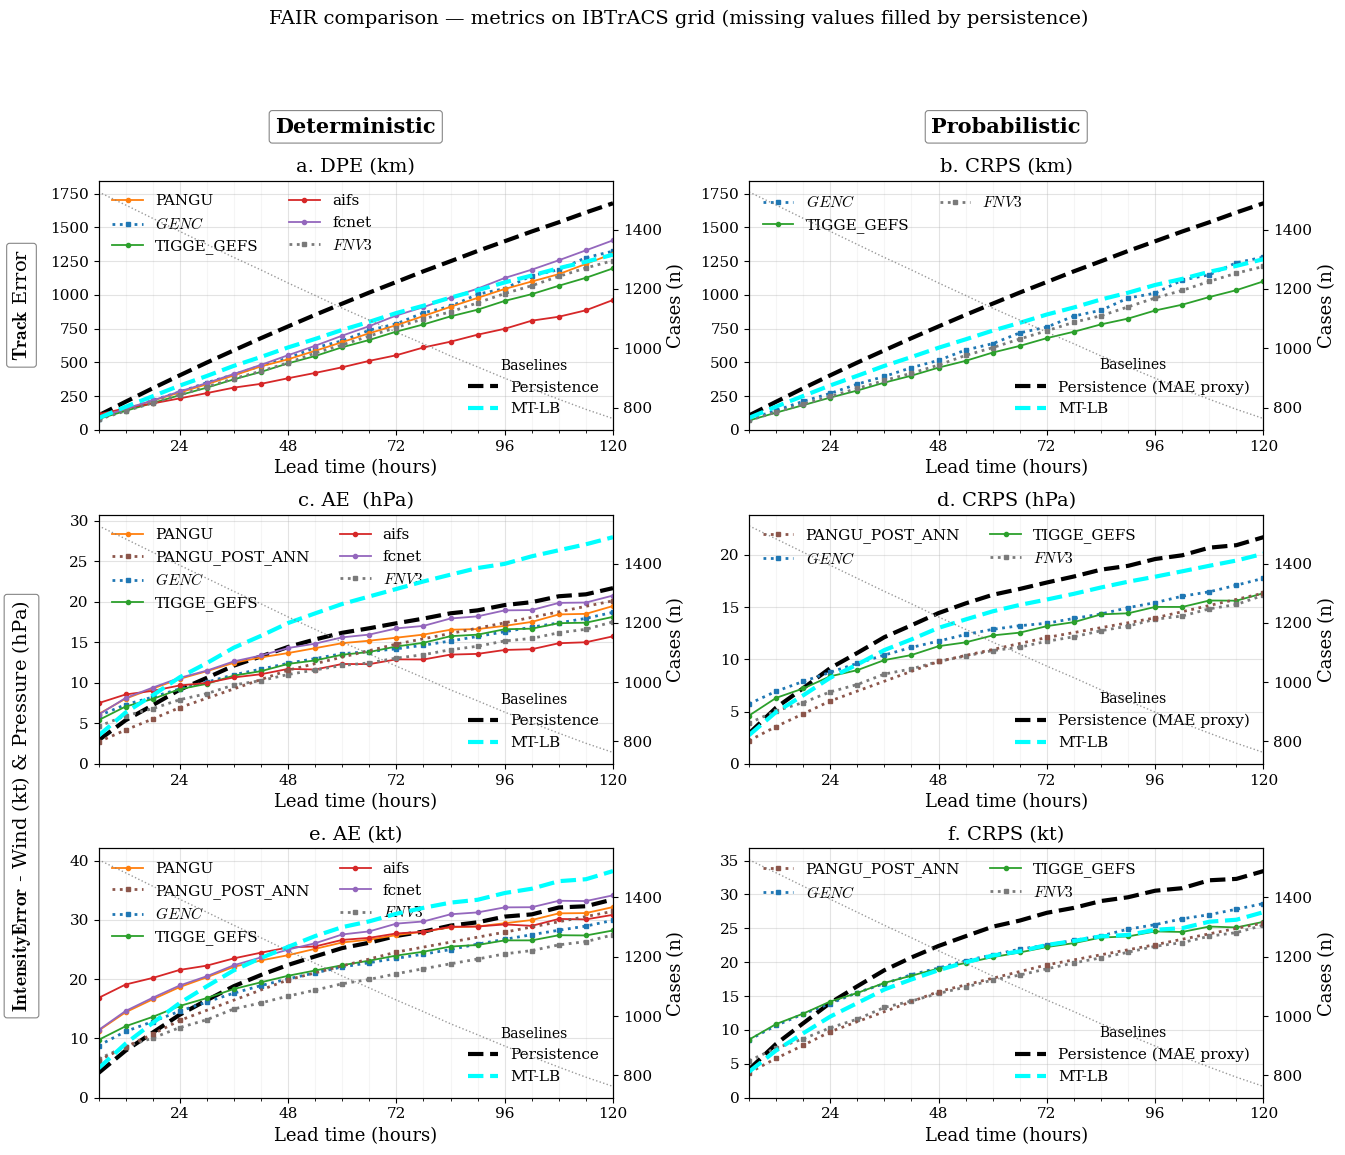

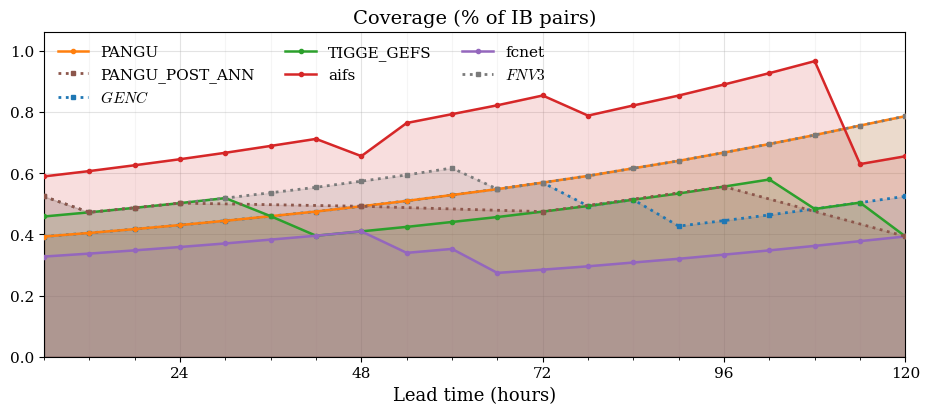

<Figure size 640x480 with 0 Axes>

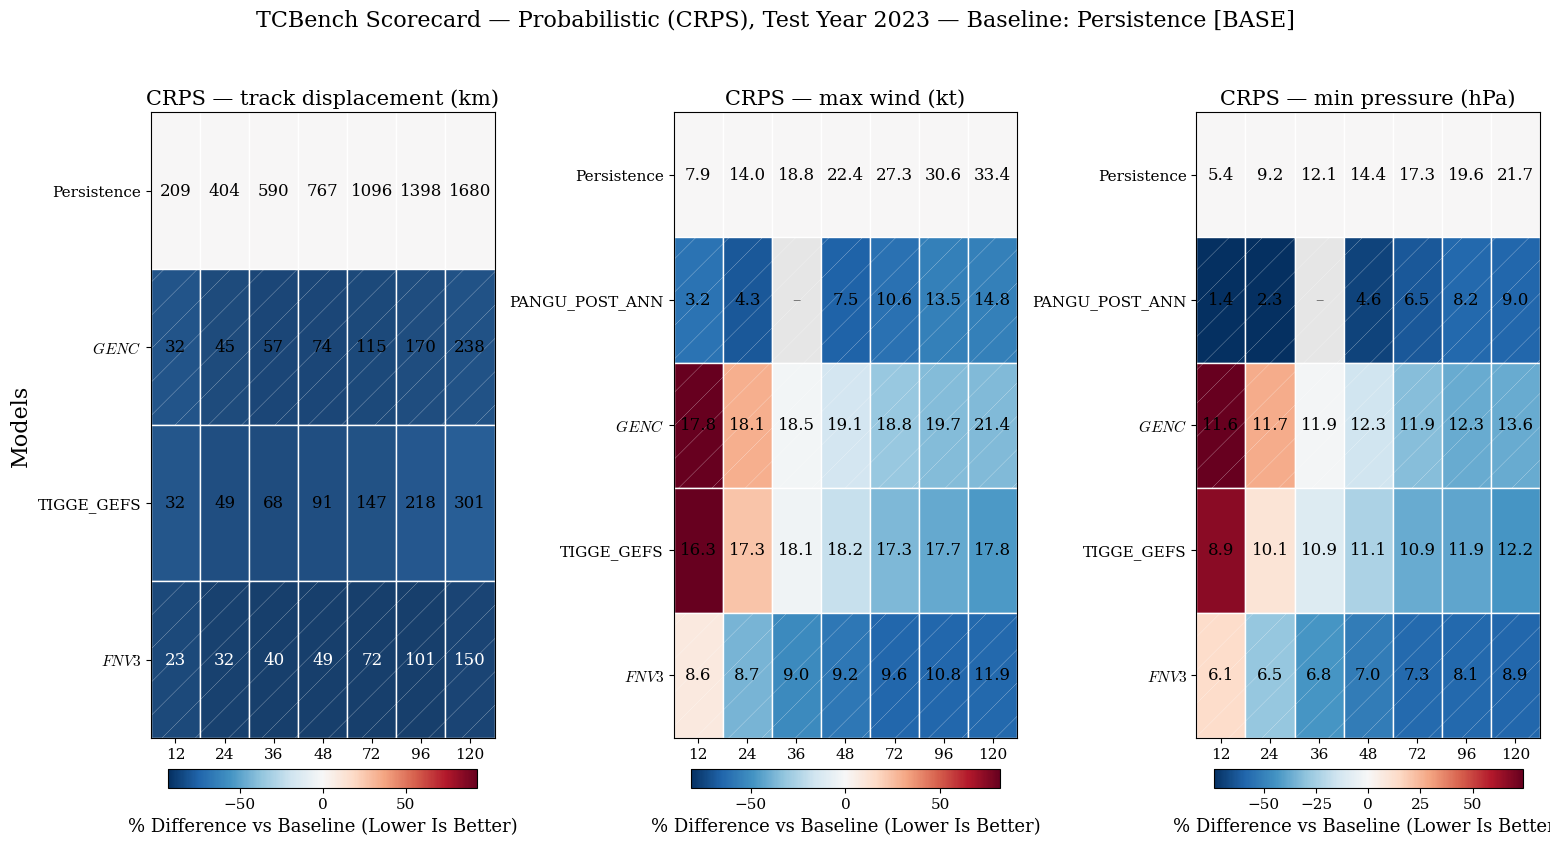

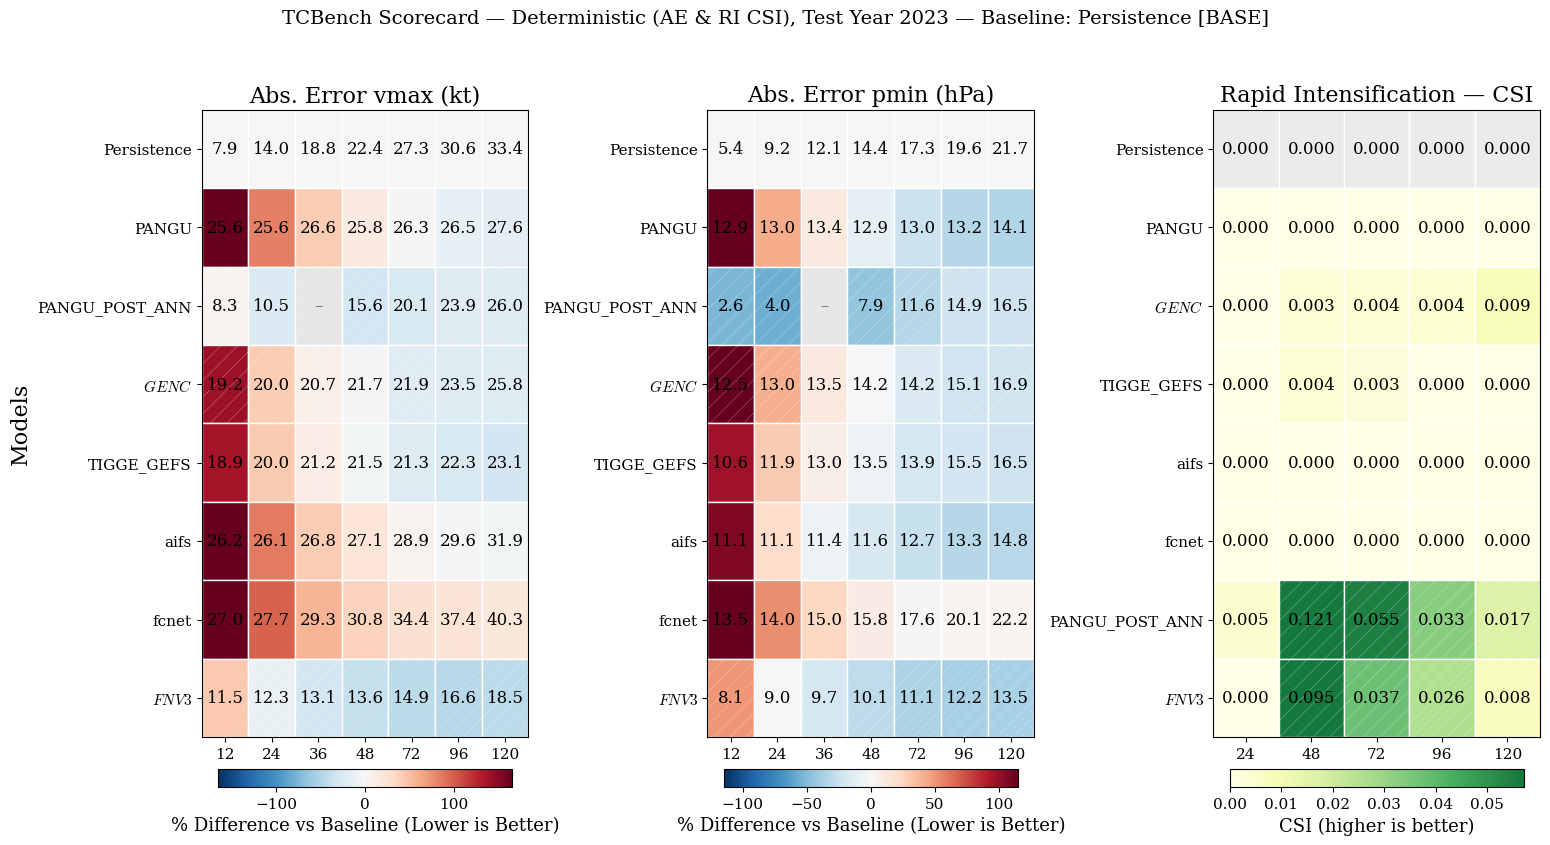

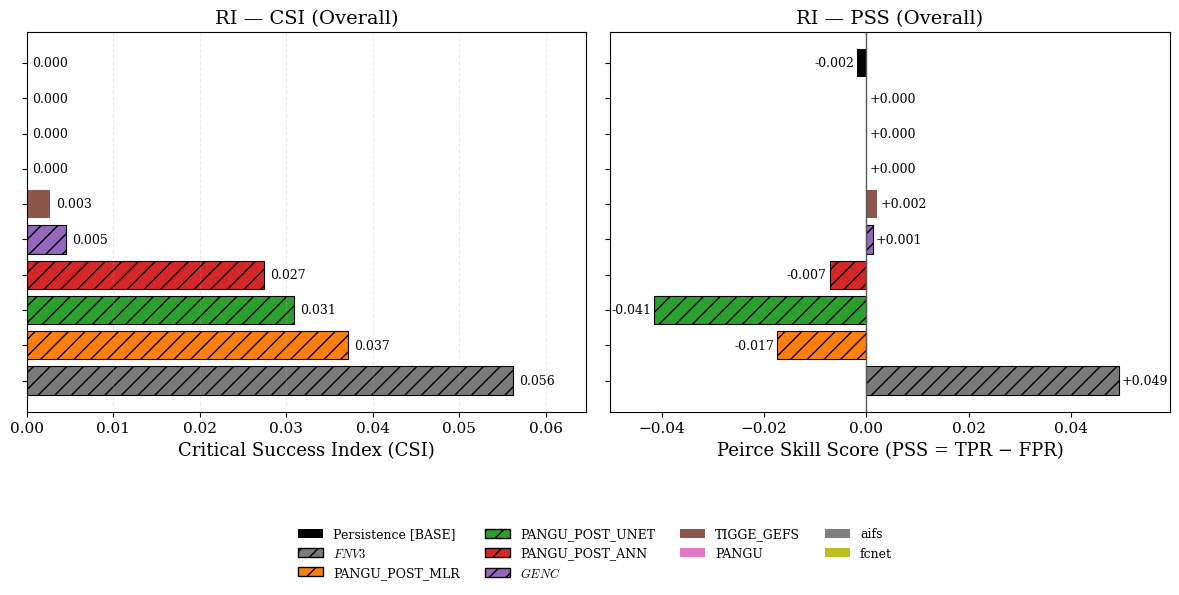

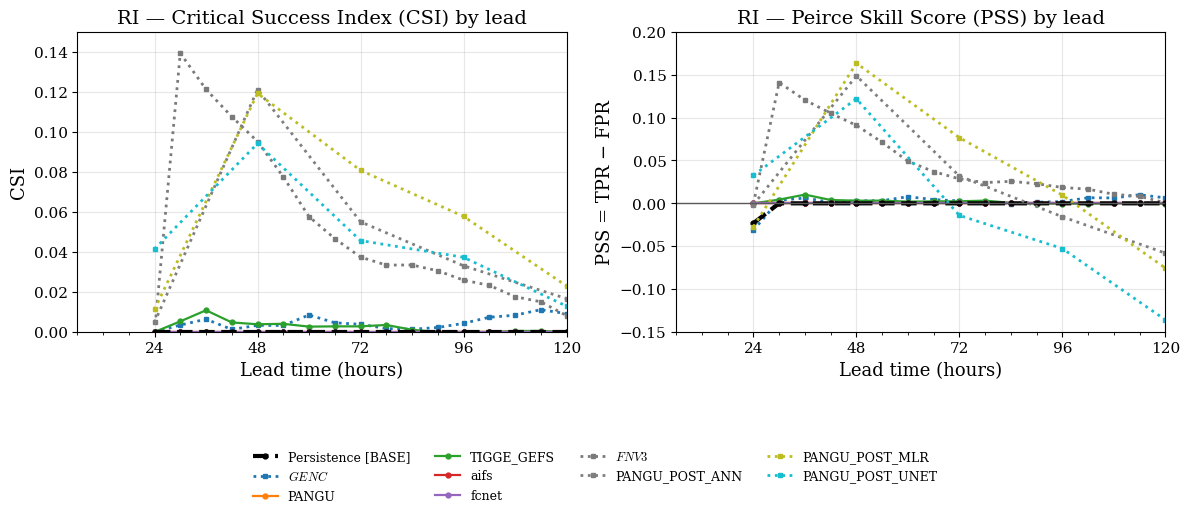

In [14]:
%run -i test.py \
    --eval_dir "/home/mgomezd1/Downloads/TCBench/outputs" \
    --ibtracs_path "/home/mgomezd1/Downloads/TCBench/data/ibtracs"
    # --figure raw fair tiered \
    # --output TCBench_2023 --format pdf --no-save